In [37]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import load_breast_cancer, make_moons, make_circles, make_classification
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Zadanie 8

In [25]:
bc = load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {'early_stopping_t': MLPClassifier(solver='adam', hidden_layer_sizes=(64,32), max_iter=1000, early_stopping=True, random_state=42, validation_fraction=0.15),
          'early_stopping_f': MLPClassifier(solver='adam', hidden_layer_sizes=(64,32), max_iter=1000, early_stopping=False, random_state=42)}

results = {}
for k, v in models.items():
    start = time.time()
    v.fit(X_train, y_train)
    accuracy = v.score(X_test, y_test)
    elapsed = round(time.time() - start, 3)
    results[k] = {'Accuracy': accuracy, 'Time (s)': elapsed, 'Epochs': v.n_iter_, 'Loss_curve': v.loss_curve_}

df = pd.DataFrame(results).loc[['Accuracy', 'Time (s)', 'Epochs']].transpose()
df

,Accuracy,Time (s),Epochs
early_stopping_t,0.964912,0.041,29
early_stopping_f,0.973684,0.196,155


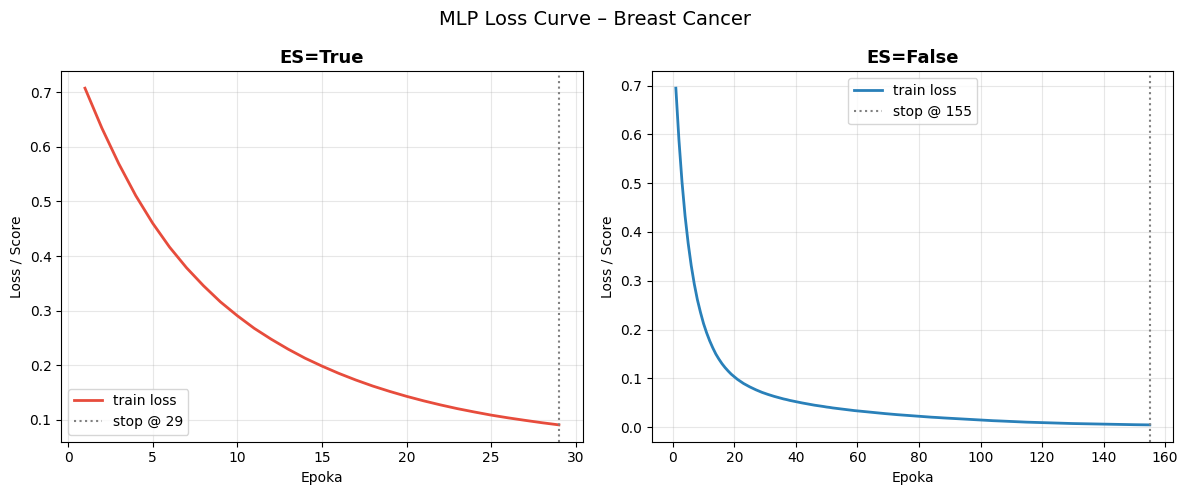

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'early_stopping_t': '#e74c3c', 'early_stopping_f': '#2980b9'}
labels = {'early_stopping_t': 'ES=True', 'early_stopping_f': 'ES=False'}

for ax, (k, r) in zip(axes, results.items()):
    epochs = range(1, len(r['Loss_curve']) + 1)

    ax.plot(epochs, r['Loss_curve'], color=colors[k], lw=2, label='train loss')

    ax.axvline(r['Epochs'], color='gray', linestyle=':', lw=1.5,
               label=f"stop @ {r['Epochs']}")

    ax.set_title(labels[k], fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoka')
    ax.set_ylabel('Loss / Score')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('MLP Loss Curve – Breast Cancer', fontsize=14)
plt.tight_layout()
plt.show()


### Zadanie 16

In [35]:
solvers = ['lbfgs', 'sgd', 'adam']
X_mo, y_mo = make_moons(n_samples=500, noise=0.2, random_state=42)
X_ci, y_ci = make_circles(n_samples=500, noise=0.2, random_state=42)
X_cl, y_cl = make_classification(n_samples=500, random_state=42, n_features=2, n_redundant=0, n_informative=2)
datasets = {'moons': (X_mo, y_mo), 'circles': (X_ci, y_ci), 'classification': (X_cl, y_cl)}

splits = {}
for name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    splits[name] = (X_train, X_test, y_train, y_test)

results = {}
pipelines = {}
for name, (X_train, X_test, y_train, y_test) in splits.items():
    results[name] = {}
    pipelines[name] = {}
    for solver in solvers:
        pipeline = make_pipeline(StandardScaler(), MLPClassifier(solver=solver, max_iter=3000, batch_size=32, hidden_layer_sizes=(16,8), random_state=42))
        pipeline.fit(X_train, y_train)
        accuracy = pipeline.score(X_test, y_test)
        results[name][solver] = accuracy
        pipelines[name][solver] = pipeline

df = pd.DataFrame(results).transpose()
print("Accuracy:")
df

Accuracy:


,lbfgs,sgd,adam
moons,0.96,0.98,0.98
circles,0.55,0.64,0.66
classification,0.93,0.93,0.94


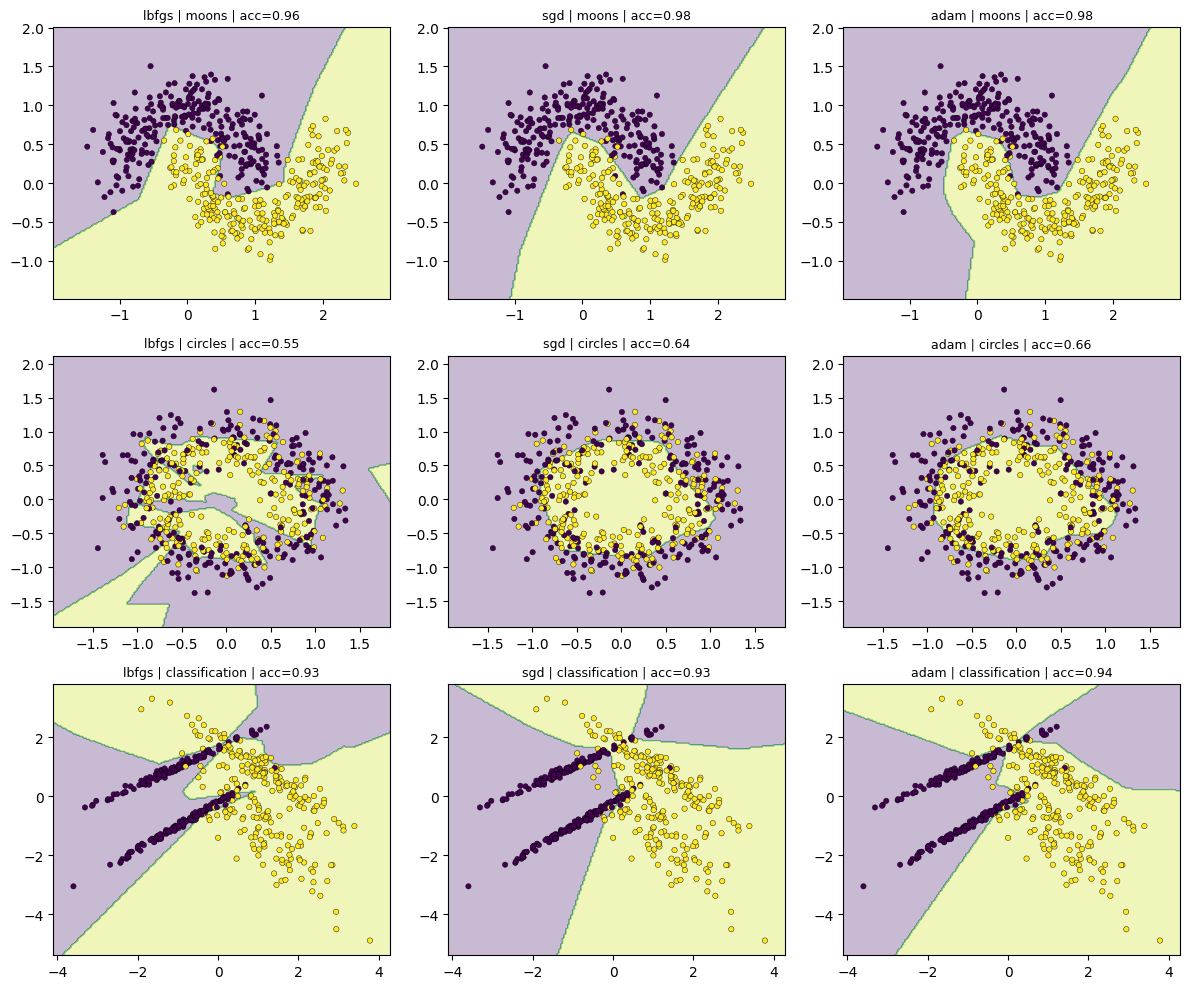

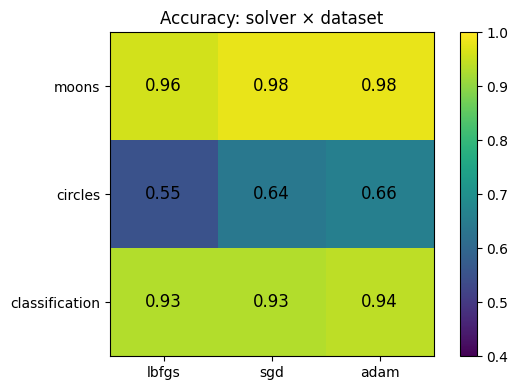

In [38]:
dataset_list = list(datasets.keys())
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for col, solver in enumerate(solvers):
    for row, name in enumerate(dataset_list):
        ax = axes[row][col]
        X_train, X_test, y_train, y_test = splits[name]
        X_all = np.vstack([X_train, X_test])
        y_all = np.concatenate([y_train, y_test])

        xx, yy = np.meshgrid(
            np.linspace(X_all[:, 0].min() - 0.5, X_all[:, 0].max() + 0.5, 200),
            np.linspace(X_all[:, 1].min() - 0.5, X_all[:, 1].max() + 0.5, 200)
        )
        Z = pipelines[name][solver].predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3)
        ax.scatter(X_all[:, 0], X_all[:, 1], c=y_all, s=15, edgecolors='k', linewidths=0.3)
        ax.set_title(f'{solver} | {name} | acc={results[name][solver]:.2f}', fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(df.values, vmin=0.4, vmax=1.0)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(solvers)));      ax.set_xticklabels(solvers)
ax.set_yticks(range(len(dataset_list))); ax.set_yticklabels(dataset_list)
ax.set_title('Accuracy: solver × dataset')
for i in range(len(dataset_list)):
    for j in range(len(solvers)):
        ax.text(j, i, f'{df.values[i, j]:.2f}', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()